In [11]:
import pandas as pd

df = pd.read_csv(r'C:\Users\juanb\Desktop\IronHack\Proyecto final\ChurnGuard\data\archive (2)\WA_Fn-UseC_-Telco-Customer-Churn.csv', low_memory=False)


In [12]:
df.head ()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [13]:
df.info

<bound method DataFrame.info of       customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female              0     Yes         No       1   
1     5575-GNVDE    Male              0      No         No      34   
2     3668-QPYBK    Male              0      No         No       2   
3     7795-CFOCW    Male              0      No         No      45   
4     9237-HQITU  Female              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
0              No  No phone service             DSL 

In [14]:
df.shape

(7043, 21)

In [15]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [16]:
df['TotalCharges'].unique()

<StringArray>
[  '29.85',  '1889.5',  '108.15', '1840.75',  '151.65',   '820.5',  '1949.4',
   '301.9', '3046.05', '3487.95',
 ...
 '2625.25', '6886.25',  '1495.1',   '743.3',  '1419.4',  '1990.5',  '7362.9',
  '346.45',   '306.6',  '6844.5']
Length: 6531, dtype: str

In [17]:
df[df['TotalCharges'] == ' '].shape

(11, 21)

In [18]:
#Eliminar customerID
df.drop('customerID', axis=1, inplace=True)


In [19]:
# Forma A — función de pandas
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)

# Forma B — método de Serie (esto NO existe)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)

In [20]:
# Cambar el tipo de dato a float
df['TotalCharges'] = df['TotalCharges'].astype(float)
print(df['TotalCharges'].dtype)

float64


In [21]:
# Cuantos NaN hay en TotalCharges
df['TotalCharges'].isna().sum()
print(df['TotalCharges'].dtype)

float64


In [22]:
#detectar valores nulos en totalcharges
df[df['TotalCharges'].isna()]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [23]:
df.shape

(7043, 20)

In [24]:
# Columnas actuales
df.columns


Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [25]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [26]:
print('Churn' in X.columns)
print(y.unique())

False
<StringArray>
['No', 'Yes']
Length: 2, dtype: str


In [27]:
# Medir value counts en target
print(y.value_counts())
normalize = True
print(y.value_counts(normalize=normalize))

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


In [28]:
# Medir value counts de cada columna
for col in X.columns:
    print(f'Columna: {col}')
    print(X[col].value_counts())
    print('---')
    
    

Columna: gender
gender
Male      3555
Female    3488
Name: count, dtype: int64
---
Columna: SeniorCitizen
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64
---
Columna: Partner
Partner
No     3641
Yes    3402
Name: count, dtype: int64
---
Columna: Dependents
Dependents
No     4933
Yes    2110
Name: count, dtype: int64
---
Columna: tenure
tenure
1     613
72    362
2     238
3     200
4     176
     ... 
28     57
39     56
44     51
36     50
0      11
Name: count, Length: 73, dtype: int64
---
Columna: PhoneService
PhoneService
Yes    6361
No      682
Name: count, dtype: int64
---
Columna: MultipleLines
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64
---
Columna: InternetService
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64
---
Columna: OnlineSecurity
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: 

Boxplot para churn

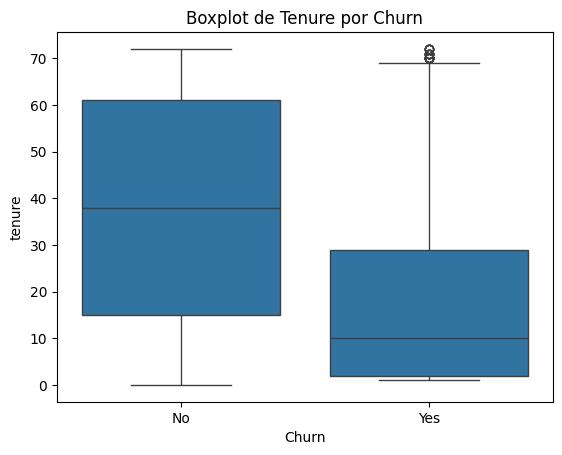

int64


In [29]:
# Boxplot de tenure por Churn = 'Yes' o 'No'
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title('Boxplot de Tenure por Churn')
plt.show()
print(df['tenure'].dtype)

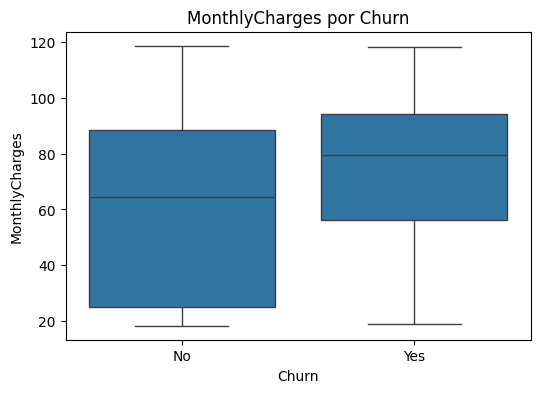

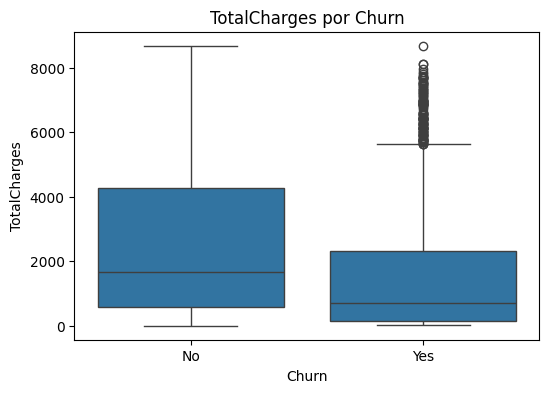

In [30]:
# MonthlyCharges vs Churn
plt.figure(figsize=(6, 4))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('MonthlyCharges por Churn')
plt.show()

# TotalCharges vs Churn
plt.figure(figsize=(6, 4))
sns.boxplot(x='Churn', y='TotalCharges', data=df)
plt.title('TotalCharges por Churn')
plt.show()

Qué indica el gráfico
La mediana de Yes está por encima de la de No.

El grupo Yes está más concentrado en rangos altos de precio mensual.

Eso sugiere que un mayor coste mensual podría estar asociado con más churn.

Interpretación de negocio
Una lectura razonable es que los clientes que pagan más al mes pueden ser más sensibles al precio y, por tanto, más propensos a abandonar el servicio.



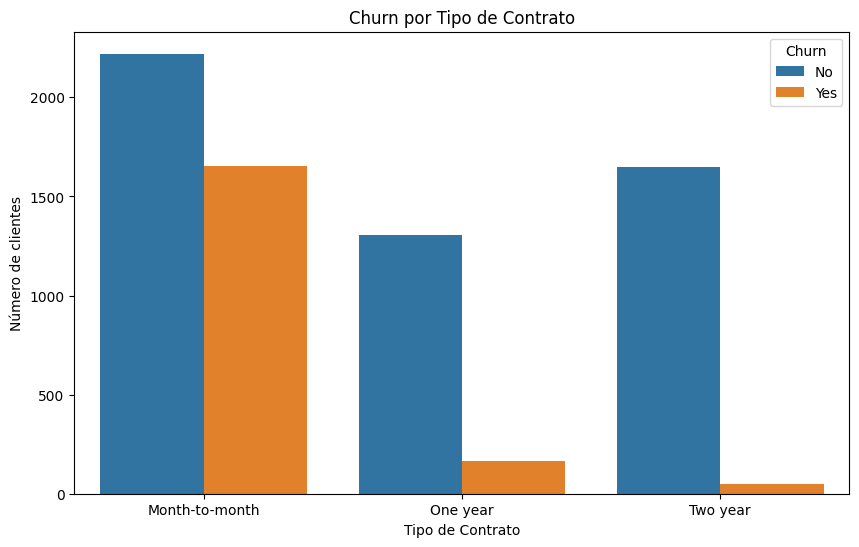

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Churn por Tipo de Contrato')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Número de clientes')
plt.show()

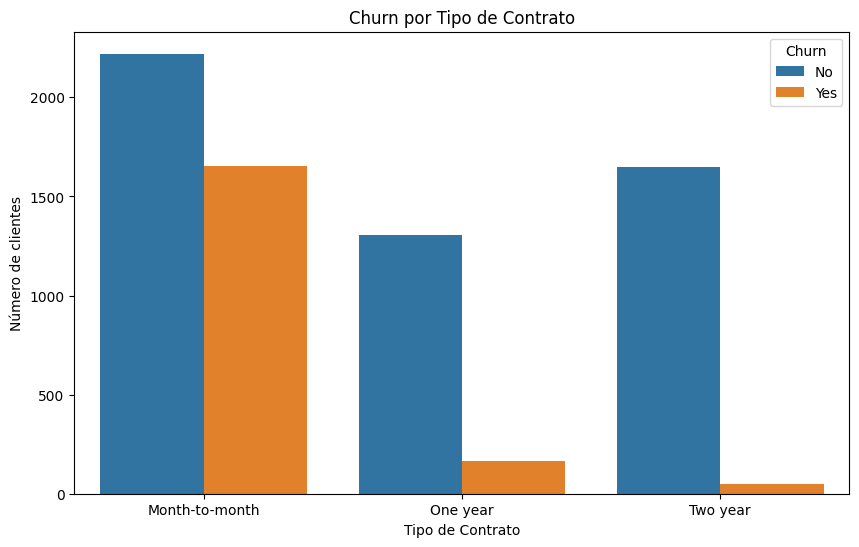

In [32]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Churn por Tipo de Contrato')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Número de clientes')
plt.show()

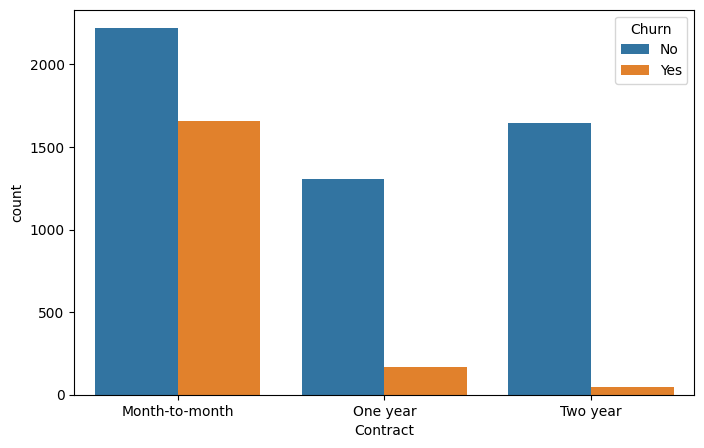

In [33]:

plt.figure(figsize=(8, 5))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.show()

In [34]:
# Reemplazar 'No internet service' por 'No' en las columnas relacionadas con servicios de internet
cols_internet = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
for col in cols_internet:
    df[col] = df[col].replace('No internet service', 'No')
# Reemplazar 'No phone service' por 'No' en la columna relacionada con servicio telefónico
df['MultipleLines'] = df['MultipleLines'].replace('No phone service', 'No')


In [35]:
# Values counts de las columnas relacionadas con servicios de internet
for col in cols_internet:
    print(f'Columna: {col}')
    print(df[col].value_counts())
    print('---')
    

Columna: OnlineSecurity
OnlineSecurity
No     5024
Yes    2019
Name: count, dtype: int64
---
Columna: OnlineBackup
OnlineBackup
No     4614
Yes    2429
Name: count, dtype: int64
---
Columna: DeviceProtection
DeviceProtection
No     4621
Yes    2422
Name: count, dtype: int64
---
Columna: TechSupport
TechSupport
No     4999
Yes    2044
Name: count, dtype: int64
---
Columna: StreamingTV
StreamingTV
No     4336
Yes    2707
Name: count, dtype: int64
---
Columna: StreamingMovies
StreamingMovies
No     4311
Yes    2732
Name: count, dtype: int64
---


In [36]:
# One-hot encoding de las columnas categóricas
df_encoded = pd.get_dummies(df, drop_first=True)
print(df_encoded.head())


   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  gender_Male  \
0              0       1           29.85         29.85        False   
1              0      34           56.95       1889.50         True   
2              0       2           53.85        108.15         True   
3              0      45           42.30       1840.75         True   
4              0       2           70.70        151.65        False   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  MultipleLines_Yes  \
0         True           False             False              False   
1        False           False              True              False   
2        False           False              True              False   
3        False           False             False              False   
4        False           False              True              False   

   InternetService_Fiber optic  ...  TechSupport_Yes  StreamingTV_Yes  \
0                        False  ...            False            False   


In [37]:
X = df.drop('Churn', axis=1)
y = df['Churn']

X_encoded = pd.get_dummies(X, drop_first=True)
print(X_encoded.head())

   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  gender_Male  \
0              0       1           29.85         29.85        False   
1              0      34           56.95       1889.50         True   
2              0       2           53.85        108.15         True   
3              0      45           42.30       1840.75         True   
4              0       2           70.70        151.65        False   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  MultipleLines_Yes  \
0         True           False             False              False   
1        False           False              True              False   
2        False           False              True              False   
3        False           False             False              False   
4        False           False              True              False   

   InternetService_Fiber optic  ...  DeviceProtection_Yes  TechSupport_Yes  \
0                        False  ...                 False           

In [38]:
X_encoded = pd.get_dummies(X, drop_first=True)
Y_encoded = y.map({'No': 0, 'Yes': 1})
print(Y_encoded.head())

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64


In [39]:
bool_cols = X_encoded.select_dtypes(include='bool').columns
X_encoded[bool_cols] = X_encoded[bool_cols].astype(int)
print(X_encoded.dtypes)

SeniorCitizen                              int64
tenure                                     int64
MonthlyCharges                           float64
TotalCharges                             float64
gender_Male                                int64
Partner_Yes                                int64
Dependents_Yes                             int64
PhoneService_Yes                           int64
MultipleLines_Yes                          int64
InternetService_Fiber optic                int64
InternetService_No                         int64
OnlineSecurity_Yes                         int64
OnlineBackup_Yes                           int64
DeviceProtection_Yes                       int64
TechSupport_Yes                            int64
StreamingTV_Yes                            int64
StreamingMovies_Yes                        int64
Contract_One year                          int64
Contract_Two year                          int64
PaperlessBilling_Yes                       int64
PaymentMethod_Credit

In [40]:
# Split de los datos en train y test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, Y_encoded, test_size=0.3, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape) 
stratify = Y_encoded
X_train, X_test, y_train, y_test = train_test_split(X_encoded, Y_encoded, test_size=0.3, random_state=42, stratify=stratify)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(4930, 23) (2113, 23) (4930,) (2113,)
(4930, 23) (2113, 23) (4930,) (2113,)


In [52]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_sample_weight

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Pesos para AdaBoost y Gradient Boosting
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# Definicion de modelos
lr  = LogisticRegression(class_weight='balanced', random_state=42)
rf  = RandomForestClassifier(class_weight='balanced', random_state=42)
ada = AdaBoostClassifier(random_state=42)
gb  = GradientBoostingClassifier(random_state=42)

# Entrenamiento
lr.fit(X_train_scaled, y_train)
rf.fit(X_train_scaled, y_train)
ada.fit(X_train_scaled, y_train, sample_weight=sample_weights)
gb.fit(X_train_scaled, y_train, sample_weight=sample_weights)

# Predicciones
y_pred_lr  = lr.predict(X_test_scaled)
y_pred_rf  = rf.predict(X_test_scaled)
y_pred_ada = ada.predict(X_test_scaled)
y_pred_gb  = gb.predict(X_test_scaled)

# Resultados
print('Logistic Regression:')
print(classification_report(y_test, y_pred_lr))

print('Random Forest:')
print(classification_report(y_test, y_pred_rf))

print('AdaBoost:')
print(classification_report(y_test, y_pred_ada))

print('Gradient Boosting:')
print(classification_report(y_test, y_pred_gb))

Logistic Regression:
              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1552
           1       0.51      0.80      0.62       561

    accuracy                           0.74      2113
   macro avg       0.71      0.76      0.71      2113
weighted avg       0.80      0.74      0.76      2113

Random Forest:
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1552
           1       0.62      0.47      0.54       561

    accuracy                           0.78      2113
   macro avg       0.72      0.68      0.70      2113
weighted avg       0.77      0.78      0.77      2113

AdaBoost:
              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1552
           1       0.51      0.79      0.62       561

    accuracy                           0.74      2113
   macro avg       0.71      0.76      0.71      2113
weighted avg       0.80     

In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(class_weight="balanced", random_state=42)
rf = RandomForestClassifier(class_weight="balanced", random_state=42)

lr.fit(X_train_scaled, y_train)
rf.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
y_pred_rf = rf.predict(X_test_scaled)
from sklearn.metrics import classification_report
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_lr))
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))


Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1552
           1       0.51      0.80      0.62       561

    accuracy                           0.74      2113
   macro avg       0.71      0.76      0.71      2113
weighted avg       0.80      0.74      0.76      2113

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1552
           1       0.62      0.47      0.54       561

    accuracy                           0.78      2113
   macro avg       0.72      0.68      0.70      2113
weighted avg       0.77      0.78      0.77      2113



Me quedo con la refresión lógica ya que el error mas caro desde el punto de vista de negocio son los falsos negativos es decir aquellos clientes que se van y no se detectan

In [44]:
%whos

Variable                 Type                      Data/Info
------------------------------------------------------------
LogisticRegression       type                      <class 'sklearn.linear_mo<...>stic.LogisticRegression'>
RandomForestClassifier   ABCMeta                   <class 'sklearn.ensemble.<...>.RandomForestClassifier'>
StandardScaler           type                      <class 'sklearn.preproces<...>ng._data.StandardScaler'>
X                        DataFrame                 Shape: (7043, 19)
X_encoded                DataFrame                 Shape: (7043, 23)
X_test                   DataFrame                 Shape: (2113, 23)
X_test_scaled            ndarray                   2113x23: 48599 elems, type `float64`, 388792 bytes (379.6796875 kb)
X_train                  DataFrame                 Shape: (4930, 23)
X_train_scaled           ndarray                   4930x23: 113390 elems, type `float64`, 907120 bytes (885.859375 kb)
Y_encoded                Series            

In [46]:
from sklearn.model_selection import GridSearchCV

param_grid = {'C': [0.01, 0.1, 1, 10, 100]}

grid_search = GridSearchCV(
    estimator=LogisticRegression(class_weight='balanced', random_state=42),
    param_grid=param_grid,
    scoring='recall',
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print("Mejor C:", grid_search.best_params_)
print("Mejor recall en CV:", round(grid_search.best_score_, 3))

Mejor C: {'C': 10}
Mejor recall en CV: 0.8


In [47]:
best_model = grid_search.best_estimator_

y_pred_optimized = best_model.predict(X_test_scaled)

print(classification_report(y_test, y_pred_optimized))

              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1552
           1       0.51      0.80      0.62       561

    accuracy                           0.74      2113
   macro avg       0.71      0.76      0.71      2113
weighted avg       0.80      0.74      0.76      2113



In [48]:
from sklearn.model_selection import GridSearchCV

param_grid = {'C': [0.01, 0.1, 1, 10, 100]}

grid_search = GridSearchCV(
    estimator=LogisticRegression(class_weight='balanced', random_state=42),
    param_grid=param_grid,
    scoring='recall',
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print("Mejor C:", grid_search.best_params_)
print("Mejor recall en CV:", round(grid_search.best_score_, 3))

Mejor C: {'C': 10}
Mejor recall en CV: 0.8


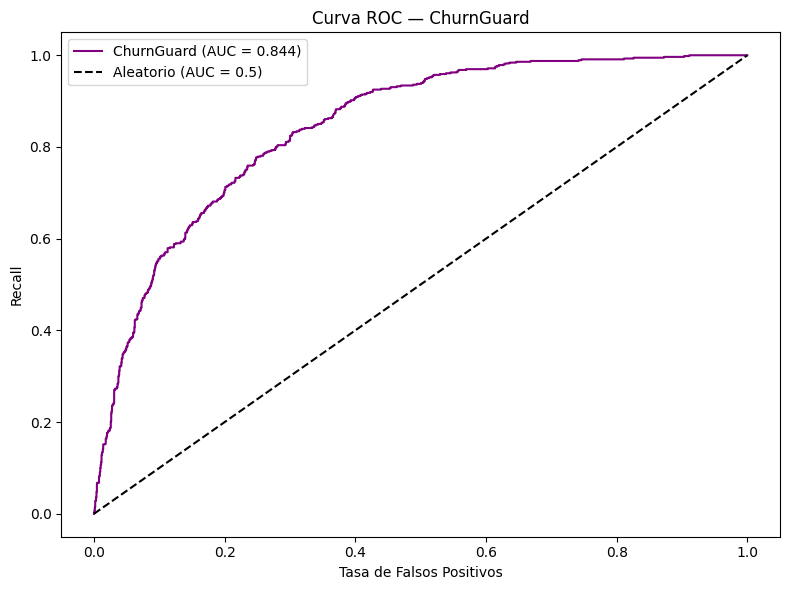

AUC: 0.844


In [49]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_proba = best_model.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='purple', label=f'ChurnGuard (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Aleatorio (AUC = 0.5)')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Recall')
plt.title('Curva ROC — ChurnGuard')
plt.legend()
plt.tight_layout()
plt.show()

print(f"AUC: {auc:.3f}")

In [50]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds_range = np.arange(0.1, 0.9, 0.05)

results = []
for t in thresholds_range:
    y_pred_t = (y_proba >= t).astype(int)
    results.append({
        'threshold': round(t, 2),
        'precision': round(precision_score(y_test, y_pred_t, zero_division=0), 3),
        'recall': round(recall_score(y_test, y_pred_t), 3),
        'f1': round(f1_score(y_test, y_pred_t), 3)
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

 threshold  precision  recall    f1
      0.10      0.342   0.988 0.508
      0.15      0.364   0.975 0.531
      0.20      0.388   0.963 0.554
      0.25      0.406   0.938 0.567
      0.30      0.429   0.927 0.586
      0.35      0.449   0.911 0.601
      0.40      0.461   0.863 0.601
      0.45      0.488   0.840 0.617
      0.50      0.509   0.797 0.621
      0.55      0.530   0.759 0.624
      0.60      0.550   0.722 0.625
      0.65      0.575   0.679 0.623
      0.70      0.611   0.608 0.609
      0.75      0.672   0.512 0.581
      0.80      0.707   0.383 0.497
      0.85      0.751   0.232 0.354


In [51]:
# Threshold elegido
threshold_final = 0.30
y_pred_final = (y_proba >= threshold_final).astype(int)

print("=== MODELO FINAL — ChurnGuard (threshold=0.30) ===")
print(classification_report(y_test, y_pred_final))

# Comparativa
print("=== COMPARATIVA ===")
print(f"{'Métrica':<12} {'Base (0.50)':>12} {'Final (0.30)':>12}")
print("-" * 38)
print(f"{'Precision':<12} {'0.509':>12} {precision_score(y_test, y_pred_final):.3f}")
print(f"{'Recall':<12} {'0.797':>12} {recall_score(y_test, y_pred_final):.3f}")
print(f"{'F1':<12} {'0.621':>12} {f1_score(y_test, y_pred_final):.3f}")
print(f"{'AUC':<12} {'0.844':>12} {'0.844':>12}")

=== MODELO FINAL — ChurnGuard (threshold=0.30) ===
              precision    recall  f1-score   support

           0       0.95      0.55      0.70      1552
           1       0.43      0.93      0.59       561

    accuracy                           0.65      2113
   macro avg       0.69      0.74      0.64      2113
weighted avg       0.81      0.65      0.67      2113

=== COMPARATIVA ===
Métrica       Base (0.50) Final (0.30)
--------------------------------------
Precision           0.509 0.429
Recall              0.797 0.927
F1                  0.621 0.586
AUC                 0.844        0.844
